In [16]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"] =os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] =os.getenv("LANGCHAIN_API_KEY")

In [17]:
from openai import OpenAI
client = OpenAI(api_key="OPENAI_API_KEY")

In [18]:


def query_llm(query: str):
    """
    Ask the LLM to explain a chemistry concept and return valid SMILES.
    - If it's a molecule or multiple molecules: return comma separated SMILES.
    - If it's a reaction: return a single reaction SMILES string.
    """

    prompt = f"""
You are an expert organic chemist specializing in synthesis design and reaction mechanisms.
Your task is to analyze the user's chemistry question and provide both a scientific explanation
and valid SMILES representation(s).

Follow these strict rules:

1. **Determine context**
   - If the query refers to a *single molecule* or *multiple molecules*:
       • Provide canonical SMILES for each molecule mentioned.
       • Use a list under "smiles".
   - If the query refers to a *reaction*:
       • Provide one valid **reaction SMILES** (reactants.SMILES>>products.SMILES).
       • Do not list individual molecules separately.

2. **Output format**
   - Return output strictly as a valid Python dictionary.
   - For molecules:
       {{
         "text": "<concise scientific explanation>",
         "smiles": "SMILES1", "SMILES2", ...
       }}
   - For reactions:
       {{
         "text": "<concise reaction explanation>",
         "smiles": "Reactant.SMILES>>Product.SMILES"
       }}

3. **Chemical accuracy**
   - Only include real, literature-consistent molecules or reactions.
   - No hypothetical compounds or unbalanced reactions.
   - Prefer canonical SMILES.

4. **Formatting**
   - Do not include markdown, backticks, or extra commentary.
   - Output must be a valid Python dictionary — parsable with `ast.literal_eval`.

Example outputs:

For multiple molecules:
{{
  "text": "Ethanol is a simple alcohol, while acetone is a common solvent with a carbonyl group.",
  "smiles": "CCO", "CC(=O)C"
}}

For a reaction:
{{
  "text": "The Suzuki coupling joins bromobenzene and phenylboronic acid via a palladium catalyst to form biphenyl.",
  "smiles": "Brc1ccccc1.B(OH)2c1ccccc1>>c1ccc(-c2ccccc2)cc1"
}}

User query: {query}
    """

    from openai import OpenAI
    client = OpenAI()  # Reads OPENAI_API_KEY from environment or Streamlit secrets

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a senior organic chemist and synthesis planner."},
            {"role": "user", "content": prompt},
        ],
    )

    return response.choices[0].message.content.strip()

In [19]:
ans1 = query_llm("Explain SN2 reaction with example. Give example using benzene system")

In [8]:
ans1

'{\n  "text": "An SN2 reaction is a one-step, bimolecular nucleophilic substitution featuring backside attack and inversion of configuration; its rate depends on both substrate and nucleophile. Benzylic halides undergo SN2 readily because the transition state is stabilized by the adjacent aromatic ring, whereas aryl C–X bonds themselves do not undergo SN2. Example on a benzene system: cyanide displaces bromide from benzyl bromide to form phenylacetonitrile.",\n  "smiles": "c1ccccc1CBr.[Na+].[C-]#N>>c1ccccc1CC#N.[Na+].[Br-]"\n}'

In [20]:
# remove newlines and parse JSON
import json
data = json.loads(ans1)

# extract smiles
smiles_rx = data["smiles"]
print(smiles_rx)


Brc1ccccc1.O[Na]>>c1ccccc(O)c1.[Na+]


In [8]:
ans = query_llm("Give two anti-infamatory drug. expalin about these drug")

In [20]:
ans

'{\n  "text": "Ibuprofen and naproxen are both nonsteroidal anti-inflammatory drugs (NSAIDs) commonly used to relieve pain, reduce inflammation, and lower fever. Ibuprofen is often used for mild to moderate pain relief, while naproxen is known for its longer duration of action.",\n  "smiles": "CC(C)C(=O)O.CC1=CC=CC=C1C(=O)O"\n}'

In [13]:
import json
# remove newlines and parse JSON
data = json.loads(ans)

# extract smiles
smiles = data["smiles"]
print(smiles)

CC(C)C(=O)O.CC1=CC=CC=C1C(=O)O


In [21]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdChemReactions
from IPython.display import display
import ast

def view_chem(smiles):
    """
    Display molecules or reactions inline.
    
    Handles:
    - Reaction SMILES (single or multiple)
    - Single molecule SMILES
    - Multiple molecule SMILES as a list or comma/dot-separated string
    """
    # Convert string representation of list to actual list if needed
    if isinstance(smiles, str) and smiles.startswith('[') and smiles.endswith(']'):
        smiles = ast.literal_eval(smiles)
    
    # If input is a list, iterate over each item
    if isinstance(smiles, list):
        for s in smiles:
            view_chem(s)  # recursively handle each item
        return
    
    # If reaction SMILES
    if ">>" in smiles:
        try:
            rxn = rdChemReactions.ReactionFromSmarts(smiles, useSmiles=True)
            if rxn is None:
                print(f"Invalid reaction SMILES skipped: {smiles}")
                return
            img = Draw.ReactionToImage(rxn, subImgSize=(200,200))
            display(img)
        except Exception as e:
            print(f"Failed to draw reaction: {smiles}\nError: {e}")
        return
    
    # Split by comma or dot for multiple molecules
    if "," in smiles:
        split_smiles = smiles.split(",")
    else:
        split_smiles = smiles.split(".")
    
    mol_list = [Chem.MolFromSmiles(smi.strip()) for smi in split_smiles]
    mol_list = [mol for mol in mol_list if mol is not None]
    
    if mol_list:
        # Draw molecules in a row
        img = Draw.MolsToGridImage(mol_list, molsPerRow=len(mol_list), subImgSize=(150,150))
        display(img)
    else:
        print(f"No valid molecules to display: {smiles}")




In [13]:
caffeine = query_llm("what is the structure of Caffeine")


In [14]:
import json
# remove newlines and parse JSON
data = json.loads(caffeine)

# extract smiles
smiles = data["smiles"]
print(smiles)

['Cn1cnc2n(C)c(=O)n(C)c(=O)c12']


Caffeine (1,3,7-trimethylxanthine) is a methylated xanthine (purine) featuring a fused imidazopyrimidine-2,6-dione core with three N-methyl groups; it is a neutral, planar heteroaromatic base.


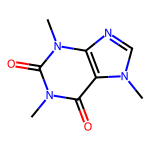

In [17]:
print(data["text"])
view_chem(smiles)


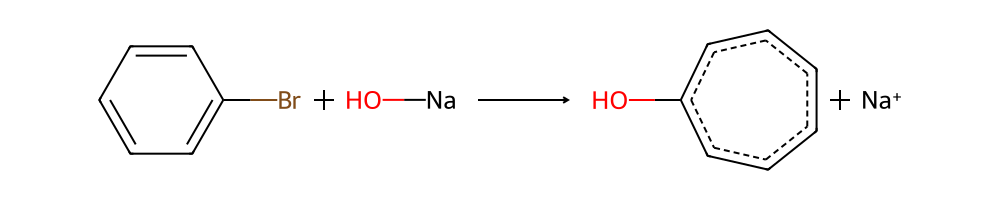

In [22]:
# ----------------------------
# Example usage

view_chem(smiles_rx)

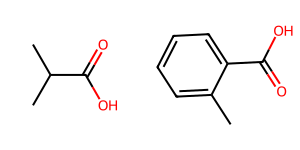

In [16]:
view_chem(smiles)

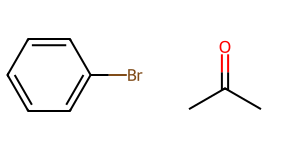

In [17]:

view_chem("Brc1ccccc1,CC(=O)C")                # Multiple molecules


In [14]:
from rdkit import Chem
from rdkit.Chem import Draw, rdChemReactions
from IPython.display import SVG, display
import ast

def view_chem_pretty(smiles):
    # Convert string representation of list to actual list if needed
    if isinstance(smiles, str) and smiles.startswith('[') and smiles.endswith(']'):
        smiles = ast.literal_eval(smiles)
    
    if isinstance(smiles, list):
        for s in smiles:
            view_chem_pretty(s)
        return
    
    # Reaction SMILES
    if ">>" in smiles:
        try:
            rxn = rdChemReactions.ReactionFromSmarts(smiles, useSmiles=True)
            if rxn is None:
                print(f"Invalid reaction SMILES skipped: {smiles}")
                return
            drawer = Draw.ReactionToImage(rxn, subImgSize=(300,300))
            display(drawer)
        except Exception as e:
            print(f"Failed to draw reaction: {smiles}\nError: {e}")
        return
    
    # Split by comma or dot for multiple molecules
    split_smiles = smiles.replace(" ", "").replace(".",",").split(",")
    mol_list = [Chem.MolFromSmiles(smi) for smi in split_smiles]
    mol_list = [mol for mol in mol_list if mol is not None]
    
    if mol_list:
        # Draw molecules in a grid, as SVG
        img = Draw.MolsToGridImage(
            mol_list, 
            molsPerRow=len(mol_list), 
            subImgSize=(250,250), 
            useSVG=True
        )
        display(SVG(img))
    else:
        print(f"No valid molecules to display: {smiles}")


In [15]:
view_chem_pretty("Brc1ccccc1,CC(=O)C")

TypeError: a bytes-like object is required, not 'SVG'

In [37]:
from IPython.display import display, HTML
import json

def draw_multiple_smiles(smiles_list, canvas_width=400, canvas_height=250, theme='light', per_row=3):
    """
    Draw multiple molecules or reactions in a grid using SmilesDrawer 2.0 in Jupyter Notebook.
    """
    if isinstance(smiles_list, str):
        smiles_list = [s.strip() for s in smiles_list.replace(".",",").split(",")]

    # Create HTML container and canvases
    html_code = "<div style='display:flex; flex-wrap:wrap; gap:20px;'>"
    for idx, smi in enumerate(smiles_list):
        canvas_id = f"smiles-canvas-{idx}"
        html_code += f"""
        <div style='text-align:center;'>
            <canvas id="{canvas_id}" width="{canvas_width}" height="{canvas_height}" 
                    style="border:1px solid #ccc; background:#fff;"></canvas>
        </div>
        """
    html_code += "</div>"

    # Single script block with library loaded once and parsed after load
    html_code += """
    <script>
    (function(){
        function drawAll(){
            const smilesList = """ + json.dumps(smiles_list) + """;
            for (let idx=0; idx<smilesList.length; idx++){
                const canvas_id = 'smiles-canvas-' + idx;
                SmilesDrawer.parse(smilesList[idx],
                    function(tree){
                        const drawer = new SmilesDrawer.Drawer({width:""" + str(canvas_width) + """, height:""" + str(canvas_height) + """});
                        drawer.draw(tree, canvas_id, '""" + theme + """', false);
                    },
                    function(err){ console.error("SMILES parse error for "+canvas_id, err); }
                );
            }
        }

        if (typeof SmilesDrawer === "undefined"){
            let script = document.createElement('script');
            script.src = "https://cdn.jsdelivr.net/npm/smiles-drawer@2.1.7/dist/smiles-drawer.min.js";
            script.onload = drawAll;
            document.head.appendChild(script);
        } else {
            drawAll();
        }
    })();
    </script>
    """

    display(HTML(html_code))


In [38]:
draw_multiple_smiles(["CCO", "CC(=O)O", "c1ccccc1"])

In [42]:
from IPython.display import display, HTML

display(HTML("""
<script src="https://cdn.jsdelivr.net/npm/smiles-drawer@2.1.7/dist/smiles-drawer.min.js"></script>
"""))


